<a href="https://colab.research.google.com/github/mscids2024pranita-hue/goa-rainfall-arima/blob/main/02_eda_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Exploratory Data Analysis & Visualization
**Project:** Goa Rainfall Forecasting using SARIMA
**Data:** goa_monthly_rainfall_clean.csv
**Step:** Understand the data visually before any modelling

In [4]:
# ============================================================
# SETUP — Run this every time you open this notebook
# Re-uploads zip and rebuilds the monthly CSV
# ============================================================

!pip install netCDF4 xarray -q

from google.colab import files
uploaded = files.upload()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.4 MB/s eta 0:00:00


Saving imd_rainfall-20260513T063252Z-3-001-20260530T092135Z-3-001.zip to imd_rainfall-20260513T063252Z-3-001-20260530T092135Z-3-001 (1).zip


In [5]:
import zipfile, os, re
import xarray as xr
import numpy as np
import pandas as pd

# Unzip
zip_path = "imd_rainfall-20260513T063252Z-3-001-20260530T092135Z-3-001 (1).zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("imd_data")

DATA_DIR = "imd_data/imd_rainfall-20260513T063252Z-3-001/imd_rainfall/"
GOA_LAT_MIN, GOA_LAT_MAX = 14.9, 15.7
GOA_LON_MIN, GOA_LON_MAX = 73.7, 74.3

# Get clean file list
files = sorted(os.listdir(DATA_DIR))
files = [f for f in files if re.match(r'RF25_ind\d{4}_rfp25\.nc$', f)]

# Extract Goa daily rainfall
daily_list = []
for fname in files:
    ds_yr = xr.open_dataset(DATA_DIR + fname)
    goa_yr = ds_yr['RAINFALL'].sel(
        LATITUDE  = slice(GOA_LAT_MIN, GOA_LAT_MAX),
        LONGITUDE = slice(GOA_LON_MIN, GOA_LON_MAX)
    )
    goa_daily_yr = goa_yr.mean(dim=['LATITUDE','LONGITUDE'], skipna=True)
    times = pd.DatetimeIndex(ds_yr['TIME'].values)
    daily_list.append(pd.Series(goa_daily_yr.values, index=times))
    ds_yr.close()

daily_goa = pd.concat(daily_list).sort_index()

# Build monthly series
monthly_goa = daily_goa.resample('MS').sum()

# Fix 2005
for month in range(1, 13):
    val_2004 = monthly_goa[f'2004-{month:02d}-01']
    val_2006 = monthly_goa[f'2006-{month:02d}-01']
    monthly_goa[f'2005-{month:02d}-01'] = (val_2004 + val_2006) / 2

monthly_goa.name = 'rainfall_mm'
monthly_goa.to_csv('goa_monthly_rainfall_clean.csv', header=True)
print(f"Done. Monthly series: {len(monthly_goa)} months, NaN: {monthly_goa.isna().sum()}")

Done. Monthly series: 420 months, NaN: 0


In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the clean monthly CSV we saved in notebook 01
df = pd.read_csv('goa_monthly_rainfall_clean.csv',
                 index_col=0,
                 parse_dates=True)

print(f"Shape      : {df.shape}")
print(f"Columns    : {list(df.columns)}")
print(f"Date range : {df.index[0].strftime('%b %Y')} to {df.index[-1].strftime('%b %Y')}")
print(f"NaN values : {df.isna().sum().sum()}")

Shape      : (420, 1)
Columns    : ['rainfall_mm']
Date range : Jan 1991 to Dec 2025
NaN values : 0


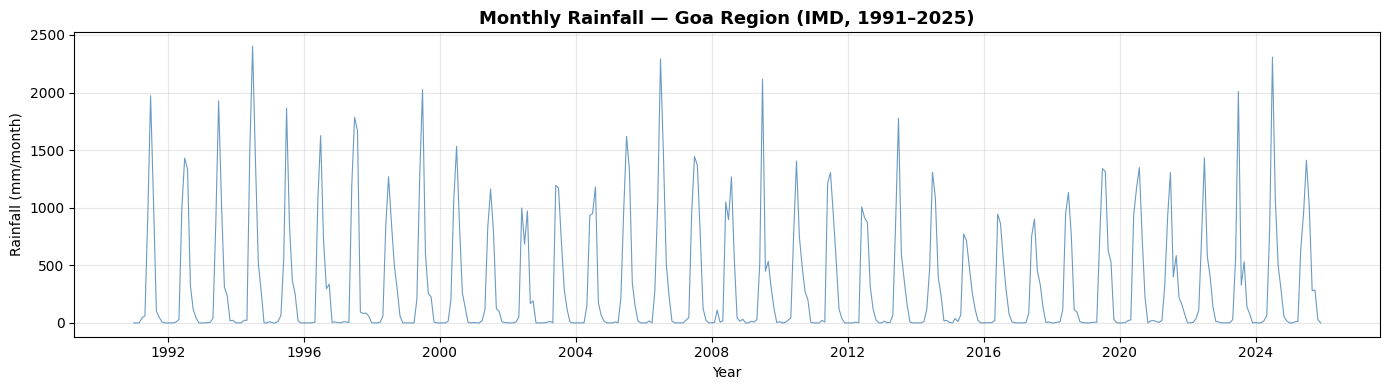

Plot saved as 01_raw_time_series.png


In [7]:
plt.figure(figsize=(14, 4))

plt.plot(df.index, df['rainfall_mm'],
         color='steelblue', linewidth=0.8, alpha=0.8)

plt.title('Monthly Rainfall — Goa Region (IMD, 1991–2025)',
          fontsize=13, fontweight='bold')
plt.ylabel('Rainfall (mm/month)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('01_raw_time_series.png', dpi=150)
plt.show()

print("Plot saved as 01_raw_time_series.png")

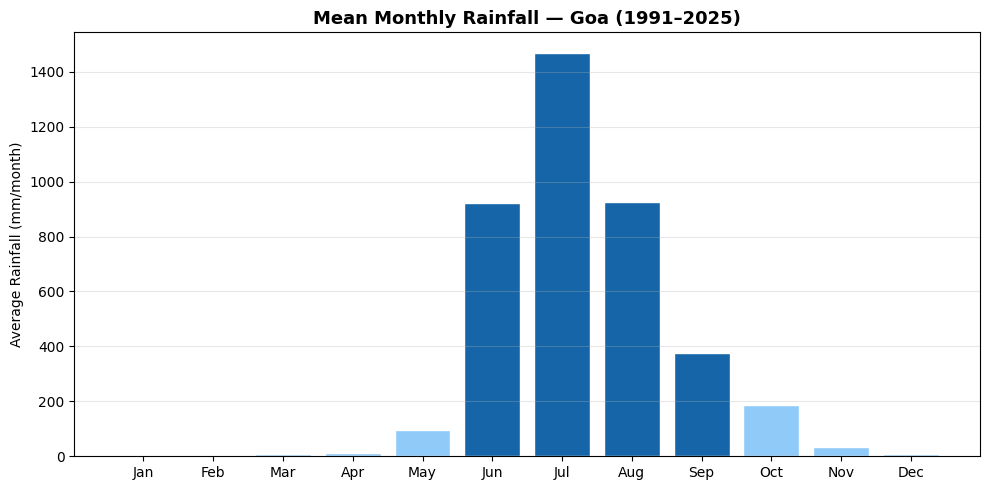


Mean rainfall by month (mm):
  Jan : 1.6
  Feb : 0.9
  Mar : 6.8
  Apr : 12.0
  May : 94.3
  Jun : 922.7
  Jul : 1470.1
  Aug : 926.5
  Sep : 376.4
  Oct : 185.9
  Nov : 33.6
  Dec : 8.3


In [8]:
# Average rainfall for each calendar month across all years
monthly_avg = df.groupby(df.index.month)['rainfall_mm'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

colors = ['#90caf9' if m not in [6,7,8,9] else '#1565a8'
          for m in range(1,13)]

plt.figure(figsize=(10, 5))
plt.bar(month_names, monthly_avg.values, color=colors, edgecolor='white')
plt.title('Mean Monthly Rainfall — Goa (1991–2025)',
          fontsize=13, fontweight='bold')
plt.ylabel('Average Rainfall (mm/month)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('02_mean_monthly_climatology.png', dpi=150)
plt.show()

print("\nMean rainfall by month (mm):")
for name, val in zip(month_names, monthly_avg.values):
    print(f"  {name} : {val:.1f}")

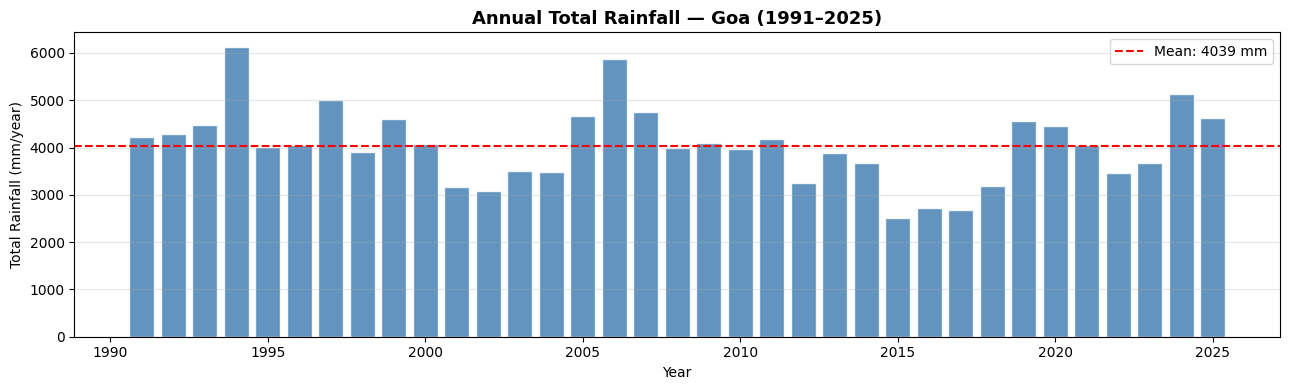

Wettest year : 1994 (6128 mm)
Driest year  : 2015 (2510 mm)
Mean annual  : 4039 mm


In [9]:
# Annual total rainfall
annual = df.resample('YE').sum()
annual.index = annual.index.year

plt.figure(figsize=(13, 4))
plt.bar(annual.index, annual['rainfall_mm'],
        color='steelblue', edgecolor='white', alpha=0.85)
plt.axhline(y=annual['rainfall_mm'].mean(),
            color='red', linewidth=1.5, linestyle='--',
            label=f"Mean: {annual['rainfall_mm'].mean():.0f} mm")
plt.title('Annual Total Rainfall — Goa (1991–2025)',
          fontsize=13, fontweight='bold')
plt.ylabel('Total Rainfall (mm/year)')
plt.xlabel('Year')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('03_annual_totals.png', dpi=150)
plt.show()

print(f"Wettest year : {annual['rainfall_mm'].idxmax()} ({annual['rainfall_mm'].max():.0f} mm)")
print(f"Driest year  : {annual['rainfall_mm'].idxmin()} ({annual['rainfall_mm'].min():.0f} mm)")
print(f"Mean annual  : {annual['rainfall_mm'].mean():.0f} mm")

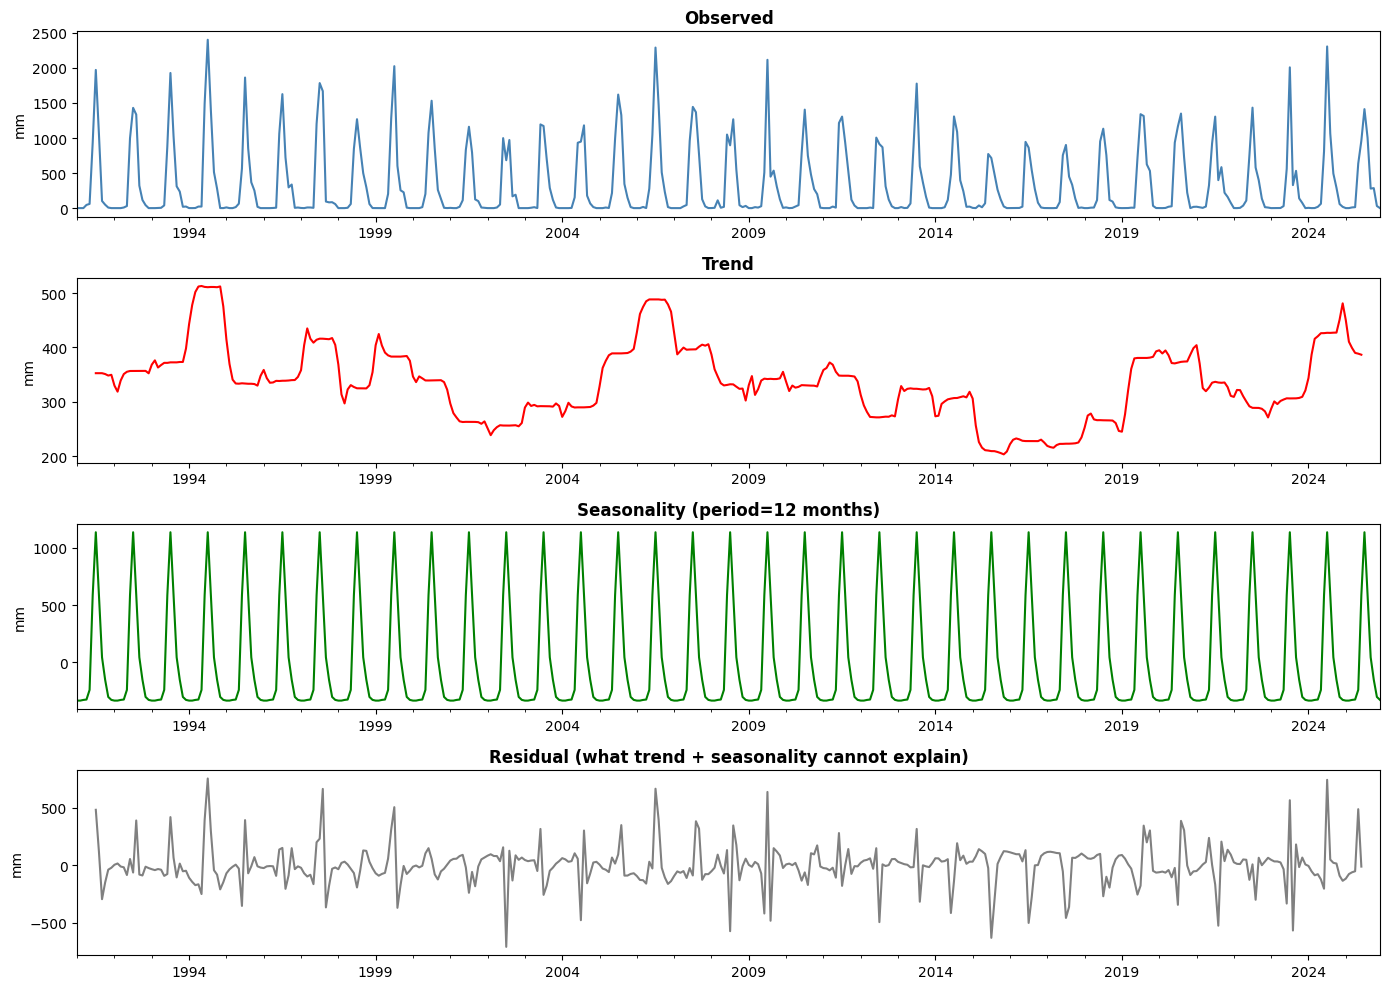

Trend range  : 203 to 513 mm
Seasonal range: -335 to 1136 mm
Residual std : 180 mm


In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['rainfall_mm'],
                                   model='additive',
                                   period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed', fontweight='bold')
axes[0].set_ylabel('mm')

decomposition.trend.plot(ax=axes[1], color='red')
axes[1].set_title('Trend', fontweight='bold')
axes[1].set_ylabel('mm')

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonality (period=12 months)', fontweight='bold')
axes[2].set_ylabel('mm')

decomposition.resid.plot(ax=axes[3], color='gray')
axes[3].set_title('Residual (what trend + seasonality cannot explain)', fontweight='bold')
axes[3].set_ylabel('mm')

plt.tight_layout()
plt.savefig('04_seasonal_decomposition.png', dpi=150)
plt.show()

print(f"Trend range  : {decomposition.trend.min():.0f} to {decomposition.trend.max():.0f} mm")
print(f"Seasonal range: {decomposition.seasonal.min():.0f} to {decomposition.seasonal.max():.0f} mm")
print(f"Residual std : {decomposition.resid.std():.0f} mm")